# Real Estate Price Predictor
The goal of this project is to build a regression model to predict median house values in Californian districts using a dataset from the 1990 U.S. Census.

The project follows these key stages:
1.  **Data Acquisition:** Download and load the dataset.
2.  **Exploratory Data Analysis (EDA):** Investigate the data to uncover patterns, correlations, and initial insights.
3.  **Data Preparation & Feature Engineering:** Clean the data, handle missing values, and construct new features to enhance model performance.
4.  **Model Training & Evaluation:** Build, train, and evaluate various regression models to find the best performer.

In [410]:
# Basic libraries
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import scipy.stats as stats

# Obtaining data
import tarfile
import urllib.request
from pathlib import Path

# Machine learning framework
import sklearn.model_selection
import sklearn.preprocessing
import sklearn.compose
import sklearn.pipeline
import sklearn.metrics
import sklearn.impute
import sklearn.base

# Models to be used
import sklearn.cluster

## 1. Getting the Data
The California housing dataset is a classic dataset for regression tasks, derived from the 1990 U.S. Census. For reproducibility, we will download it directly from an open GitHub repository.

In [411]:
# Define the URL of the dataset and the local path where it will be saved
url = "https://github.com/ageron/data/raw/main/housing.tgz"
tarball_path = Path("datasets/housing.tgz")

# Create the 'datasets' directory if it doesn't already exist
tarball_path.parent.mkdir(parents=True, exist_ok=True)

# Download the data from the URL
urllib.request.urlretrieve(url, tarball_path)

(WindowsPath('datasets/housing.tgz'),
 <http.client.HTTPMessage at 0x1fcb455e5d0>)

In [412]:
# Decompress the .tgz file to extract the housing data
with tarfile.open(tarball_path) as housing_tar:
    housing_tar.extractall(path="datasets")

C:\Users\ncesc\AppData\Local\Temp\ipykernel_29472\2366374265.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tar.extractall(path="datasets")


In [413]:
# Load the housing data into a pandas DataFrame
housing = pd.read_csv('datasets/housing/housing.csv')

# Display the first few rows for a quick overview
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 1.1. Initial Data Exploration
Let's begin by examining the dataset's structure, including data types, non-null values, and overall dimensions.

In [414]:
# Get a concise summary of the DataFrame, including data types and non-null counts
print("DataFrame Info:")
print(housing.info())

# Display the dimensions of the DataFrame (rows, columns)
print(f"\nShape of the DataFrame: {housing.shape}")

# Display the first and last few rows for a quick data preview
print("\nData Overview:")
pd.concat([housing.head(), housing.tail()])

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

Shape of the DataFrame: (20640, 10)

Data Overview:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


### 1.2. Analyzing Missing Observations
Identifying and understanding missing data is a critical step. We'll check which features have missing values and look for any patterns in their absence.

In [415]:
# Calculate the number and percentage of missing values for each feature
missing_values = housing.isna().sum()
missing_percentage = (missing_values / len(housing)) * 100

print("Missing Values per Feature:\n", missing_values)
print("\nPercentage of Missing Values:\n", missing_percentage)

Missing Values per Feature:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Percentage of Missing Values:
 longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64


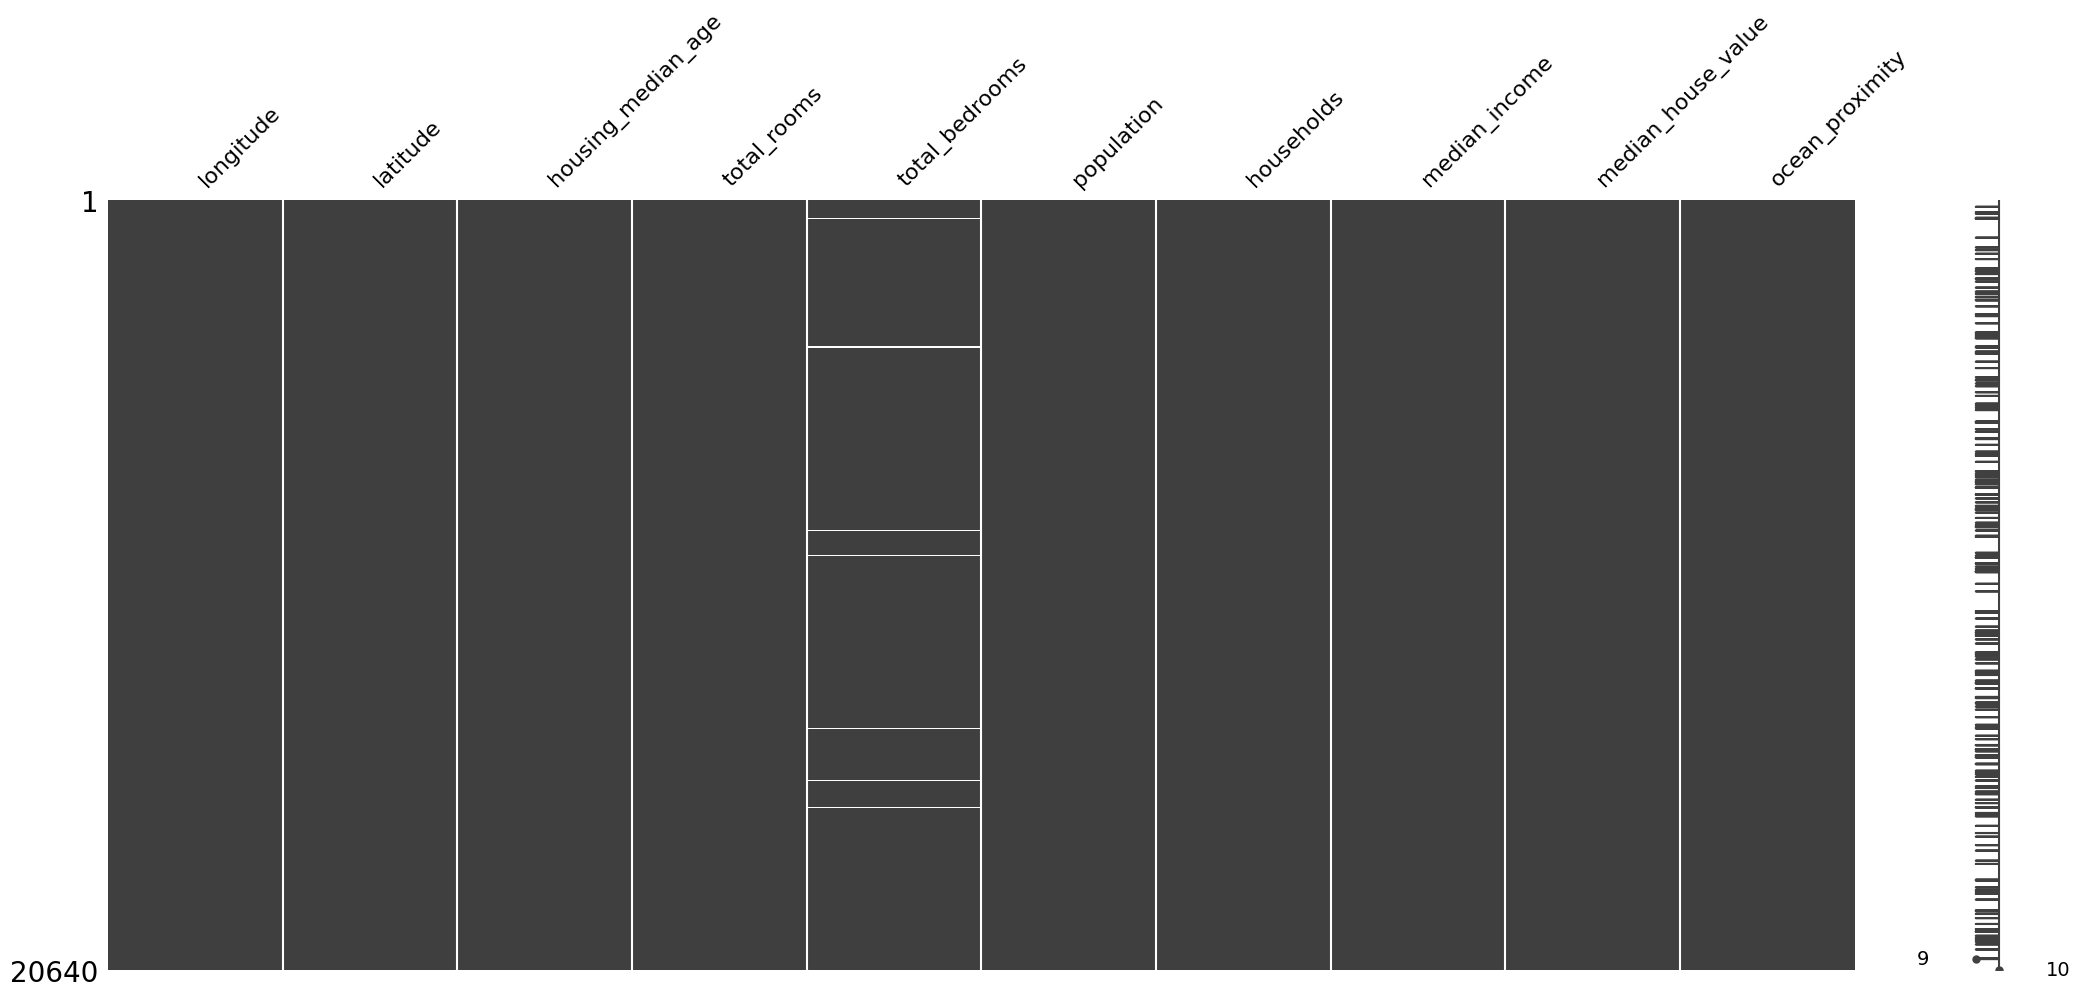

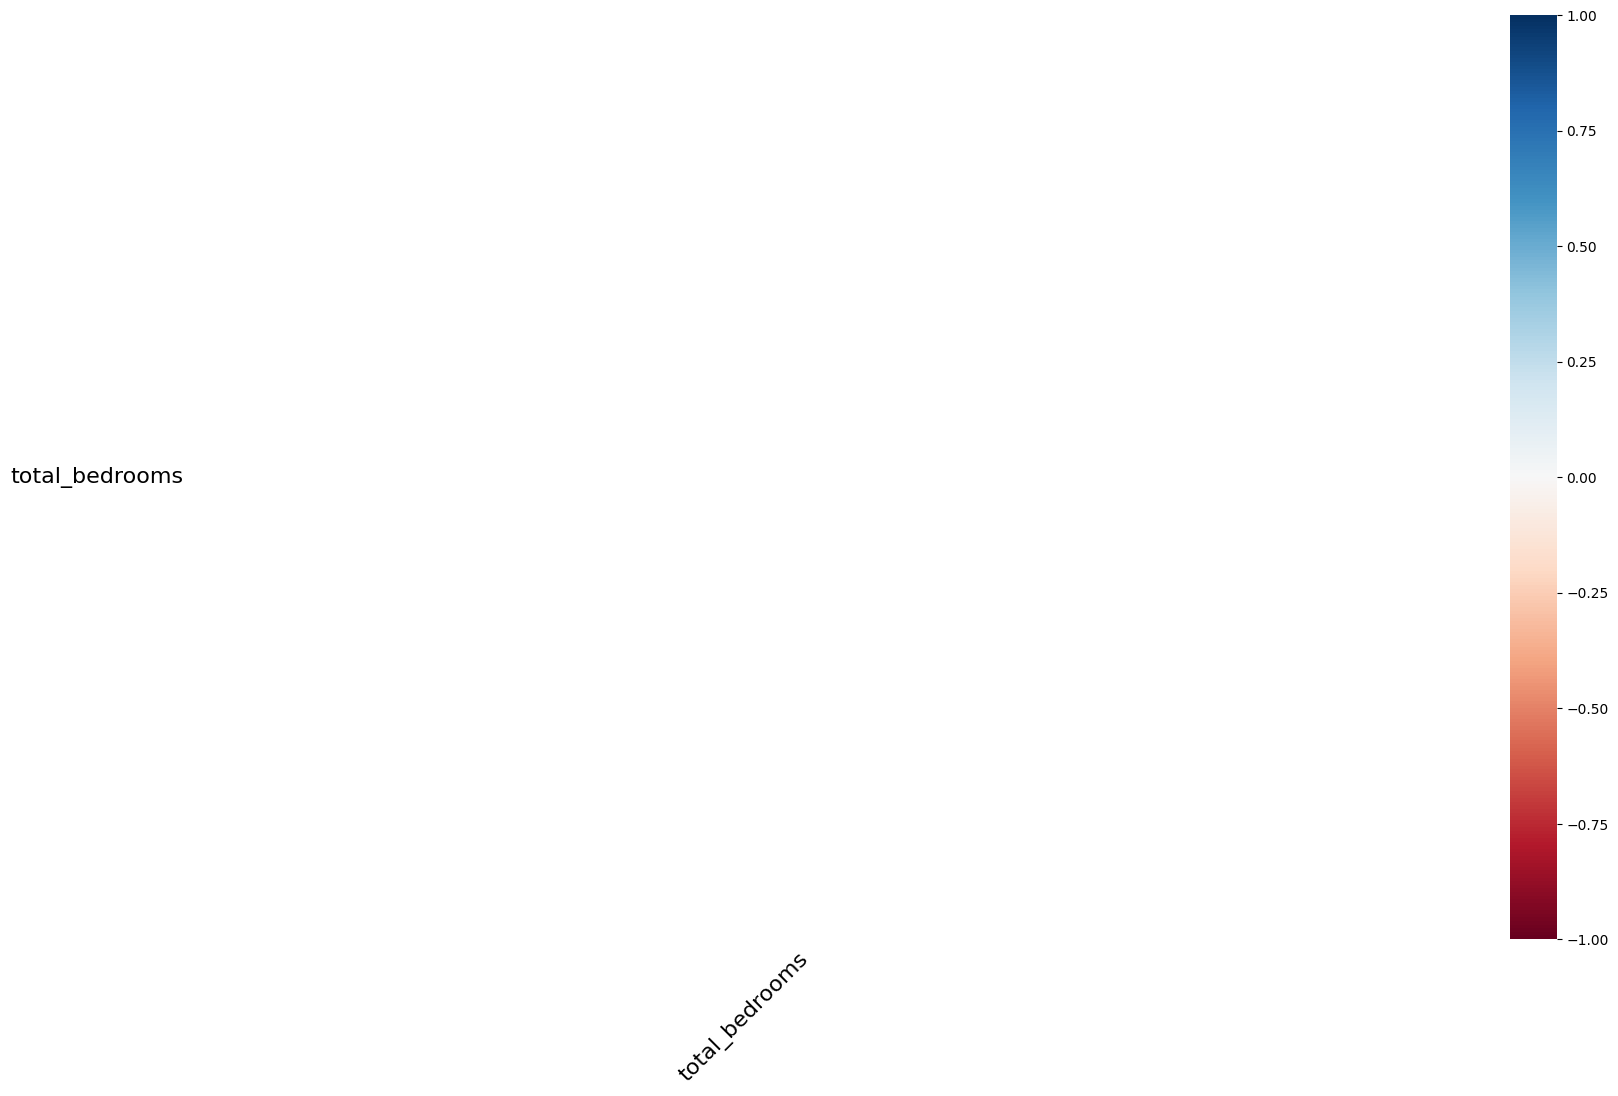

In [416]:
# Visualize the pattern of missing values
missingno.matrix(housing)
plt.show()

# Visualize the correlation of missingness between columns
missingno.heatmap(housing)
plt.show()

# The plots confirm that 'total_bedrooms' is the only feature with missing values,
# and there doesn't appear to be a strong correlation with other columns' missingness.

### 1.3. Correcting Data Types
Ensuring each column has the correct data type is important for memory efficiency and preventing errors. We'll adjust integer and categorical columns accordingly.

In [417]:
# Identify float columns that contain only integer values
integers = np.where(np.sum(housing.iloc[:, np.where(housing.dtypes != 'object')[0]] % 1, axis=0) == 0)[0]

# Convert these columns to the 'int64' data type
for col in housing.columns[integers]:
    housing[col] = housing[col].astype('int64', errors='ignore')

# Convert 'ocean_proximity' to a more memory-efficient 'category' type
housing['ocean_proximity'] = housing['ocean_proximity'].astype('category')

# Confirm the changes
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  int64   
 3   total_rooms         20640 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  int64   
 6   households          20640 non-null  int64   
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  int64   
 9   ocean_proximity     20640 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


## 2. Exploratory Data Analysis (EDA)
Now, we'll dive deeper into the data to understand feature distributions, relationships between variables, and their correlation with the target, `median_house_value`.

In [418]:
# Generate descriptive statistics for numerical features
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [419]:
# Generate descriptive statistics for categorical features
housing.describe(exclude='number')

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


In [420]:
# Evaluate skewness and kurtosis for numerical features
pd.DataFrame(np.vstack([stats.skew(housing.select_dtypes(include=['int64', 'float64']), axis=0),
                        stats.kurtosis(housing.select_dtypes(include=['int64', 'float64']), axis=0)]).T,
    columns=['Skewness', 'Kurtosis'], index = list(housing.columns[np.where(housing.dtypes != 'category')]))

,Skewness,Kurtosis
longitude,-0.297780,-1.330121
latitude,0.465919,-1.117780
housing_median_age,0.060326,-0.800726
total_rooms,4.147042,32.622732
total_bedrooms,NaN,NaN
population,4.935500,73.535009
households,3.410190,22.052354
median_income,1.646537,4.951034
median_house_value,0.977692,0.327500


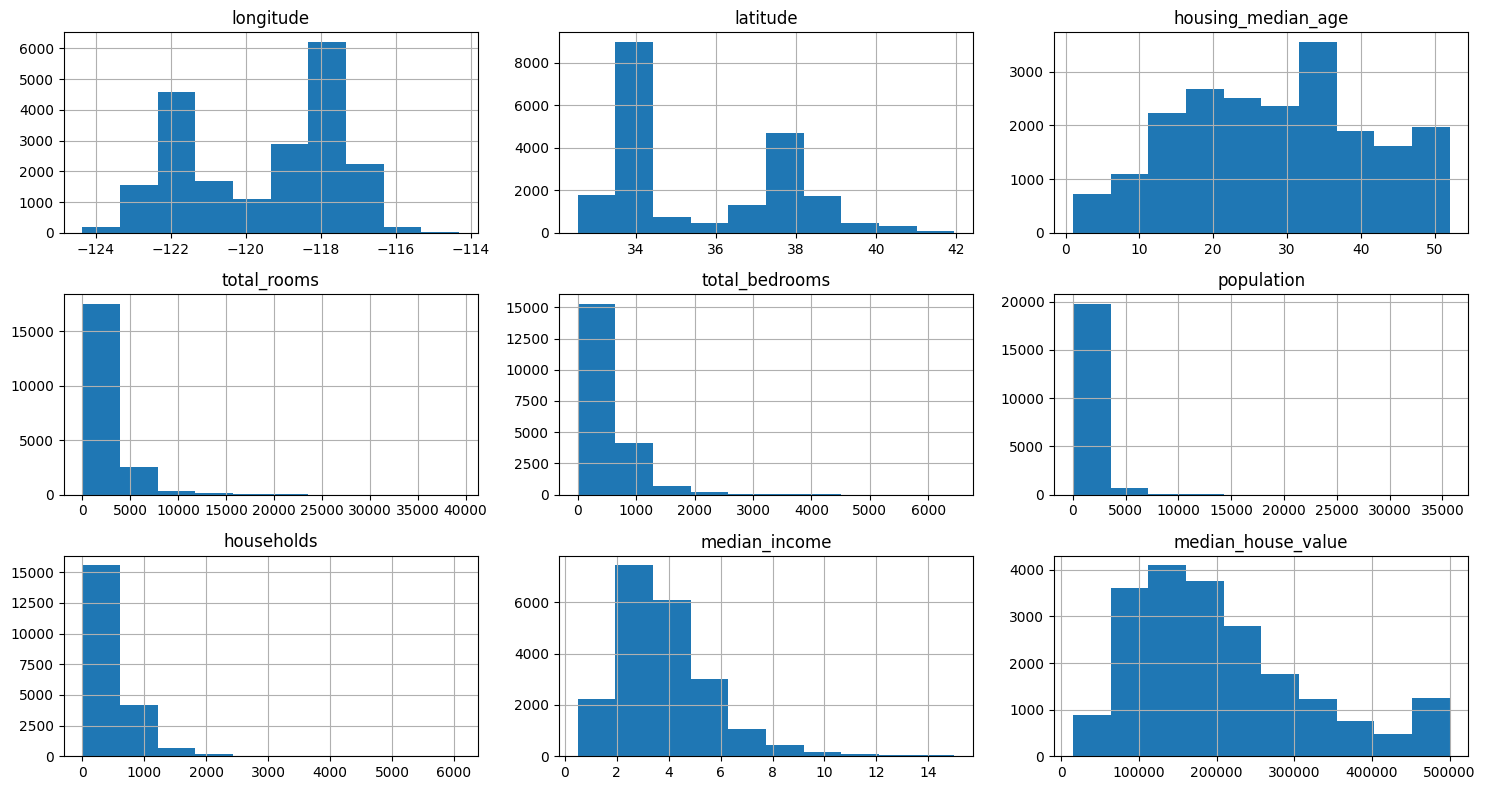

In [421]:
# Plot histograms for all numerical features to visualize their distributions
housing.hist(grid=True, figsize=(15,8))
plt.tight_layout()
plt.show()

<Figure size 1600x500 with 0 Axes>

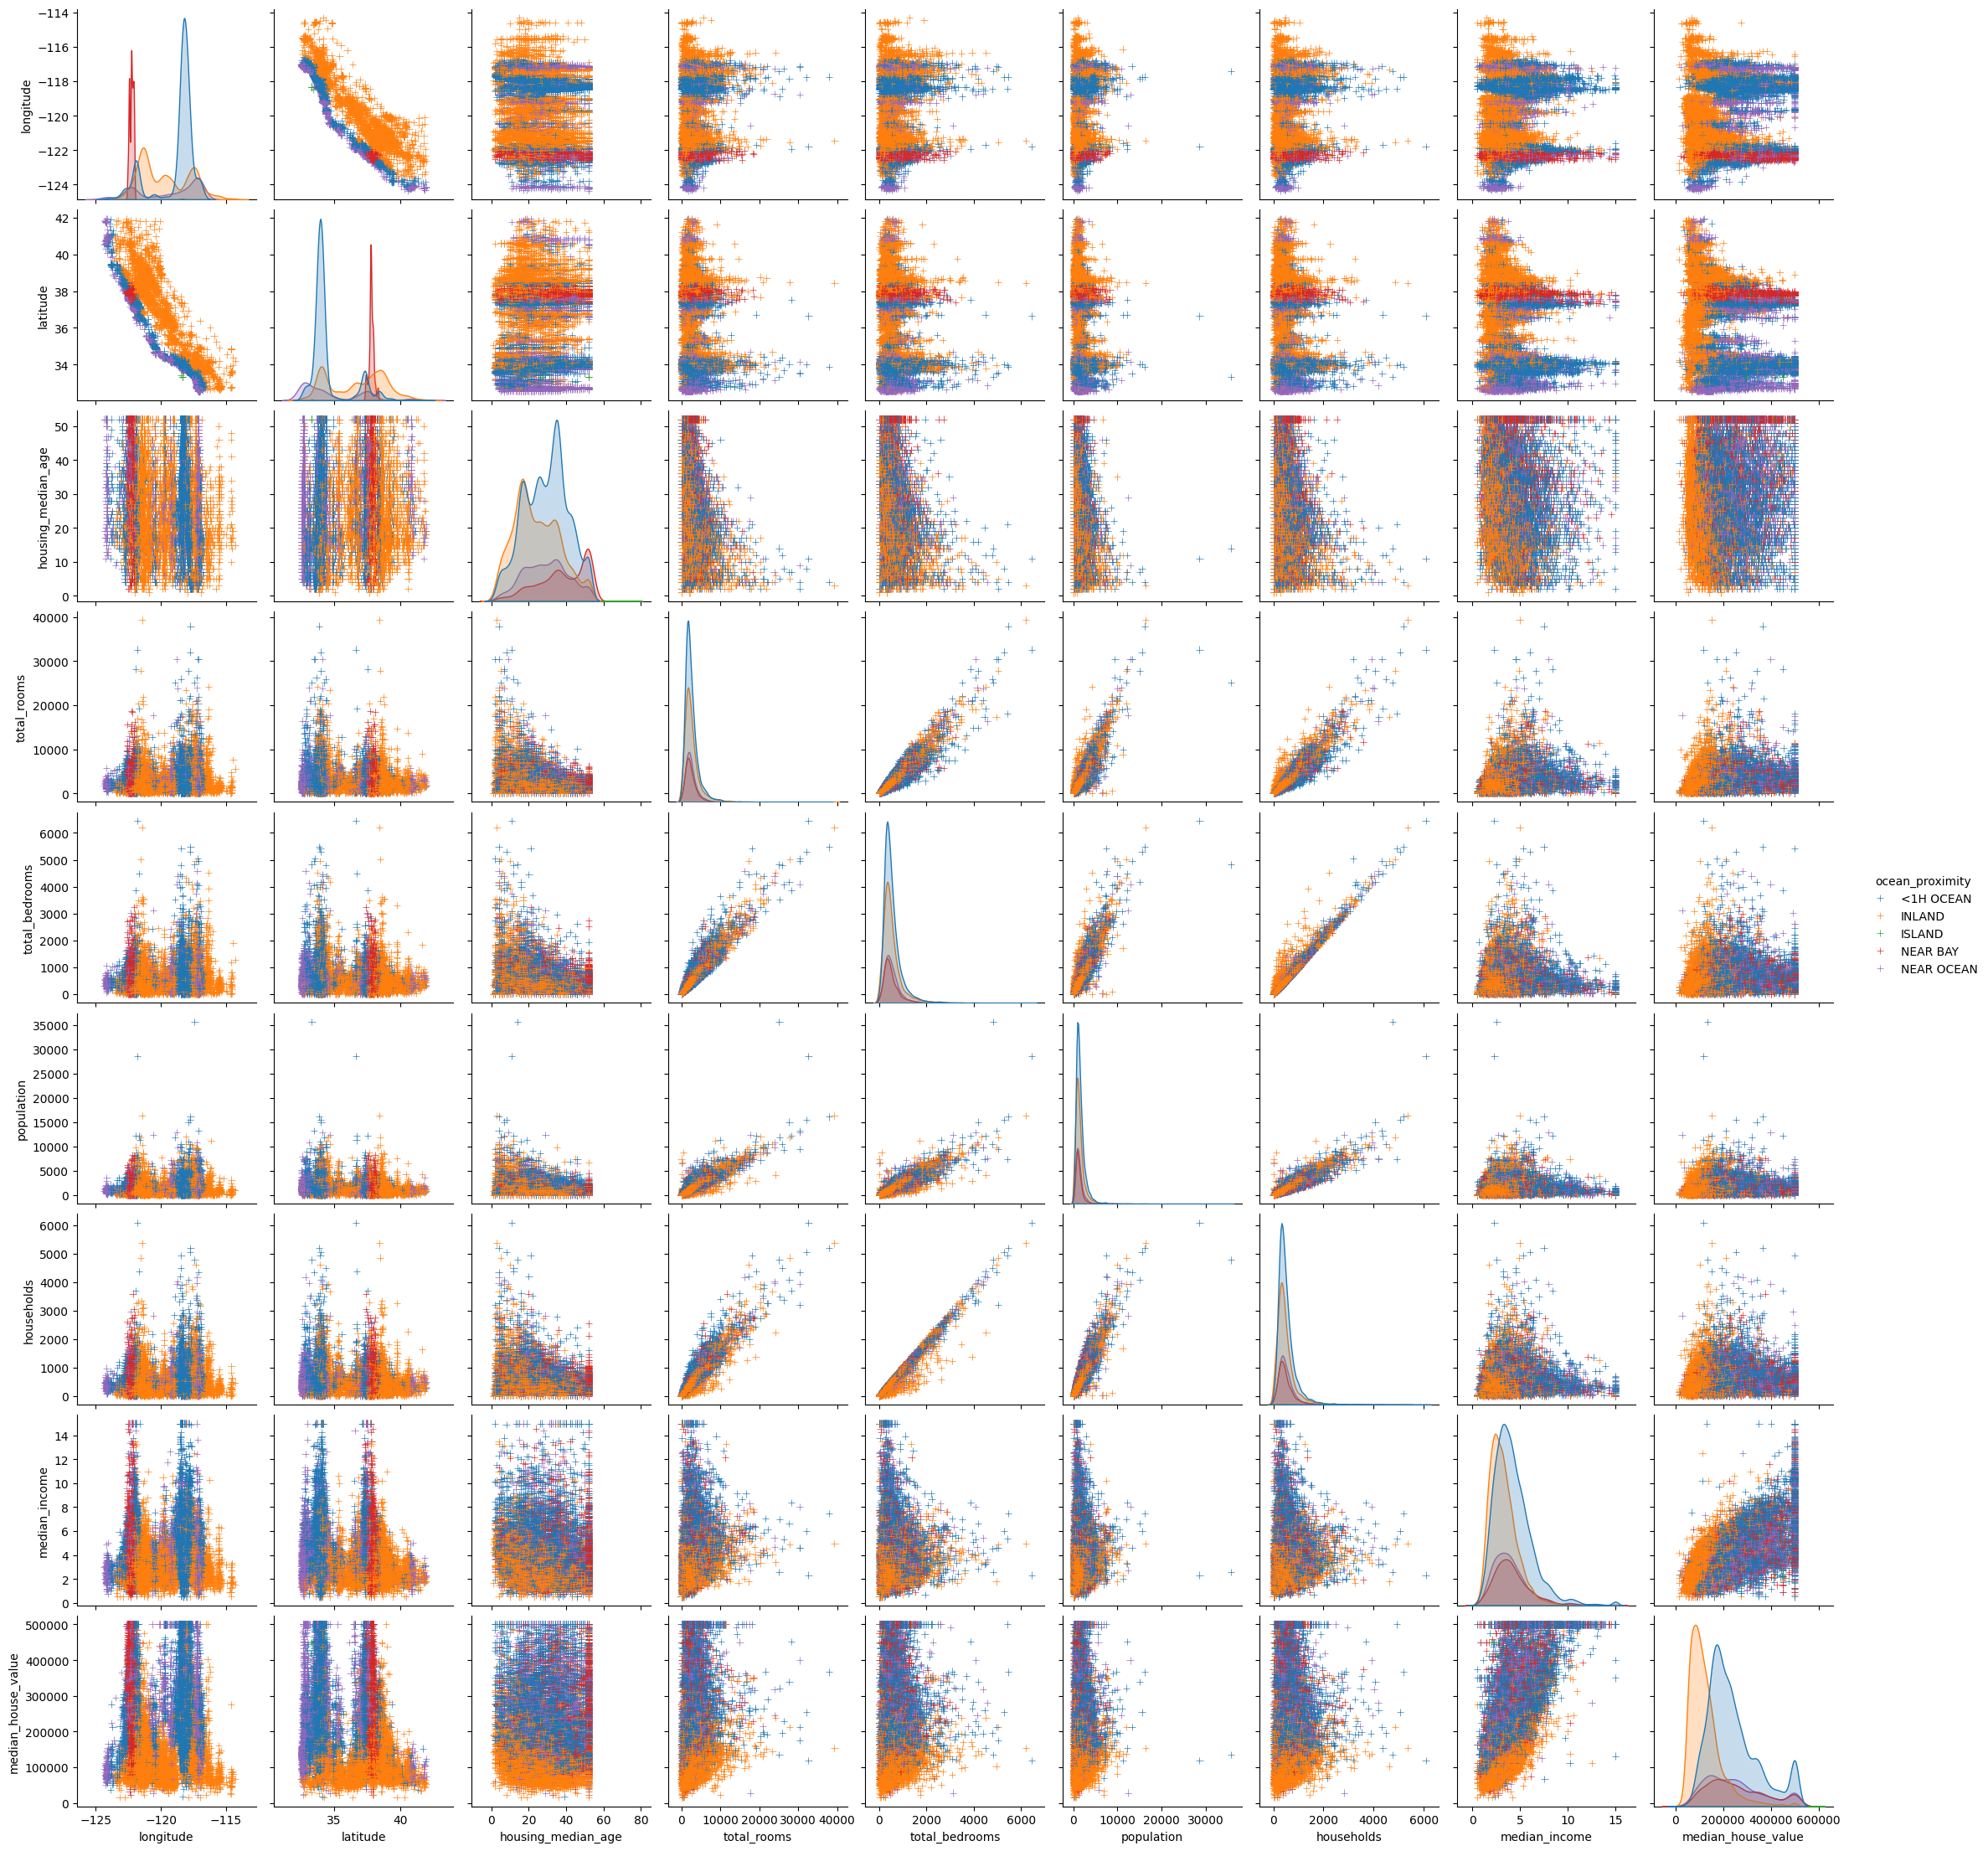

In [422]:
# Create a pairplot to visualize relationships between features, colored by ocean proximity
plt.figure(figsize = (16, 5))
sns.pairplot(housing, hue='ocean_proximity', diag_kind='kde', markers='+')
plt.show()

The histograms reveal that most numerical features have skewed distributions, which may require transformation later. The pairplot shows a positive correlation between `median_income` and `median_house_value`, and that `ocean_proximity` seems to be an important categorical feature.

### 2.1. Stratified Sampling
To ensure our training and test sets are representative of the overall data distribution, we'll use stratified sampling based on the `median_income`, which is a key feature. First, we create an income category attribute.

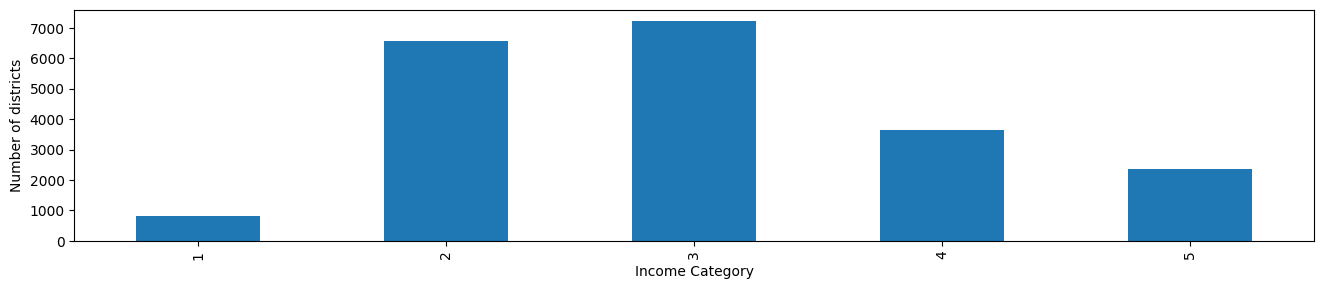

In [423]:
# Create an income category feature for stratified sampling
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5], ordered=True)

# Plot the distribution of the new income category
plt.figure(figsize= (16, 3))
housing['income_cat'].value_counts(sort=False).plot(kind='bar')
plt.xlabel('Income Category')
plt.ylabel('Number of districts')
plt.show()

In [424]:
# Set a random seed for reproducibility
SEED = 42

# Perform stratified train-test split based on the income category
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(housing.drop('median_house_value', axis=1),
                                                                            housing['median_house_value'],
                                                                            test_size=0.2,
                                                                            random_state=SEED,
                                                                            stratify=housing['income_cat'])
# Check the shape of the splits
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape, sep="\n")

(16512, 10)
(4128, 10)
(16512,)
(4128,)


In [425]:
# Verify that the income category proportions are similar in the train and test sets
print(pd.concat([x_train['income_cat'].value_counts(normalize=True).sort_index(),
                 x_test['income_cat'].value_counts(normalize=True).sort_index()],
                axis=1, keys=['Train', 'Test']))

# Remove the temporary income_cat attribute
for dataset in (x_train, x_test):
    dataset.drop('income_cat', axis=1, inplace=True)

               Train      Test
income_cat                    
1           0.039789  0.039971
2           0.318859  0.318798
3           0.350594  0.350533
4           0.176296  0.176357
5           0.114462  0.114341


### 2.2. Geographical and Correlation Analysis
Now we'll focus on the training set to explore geographical patterns and feature correlations.

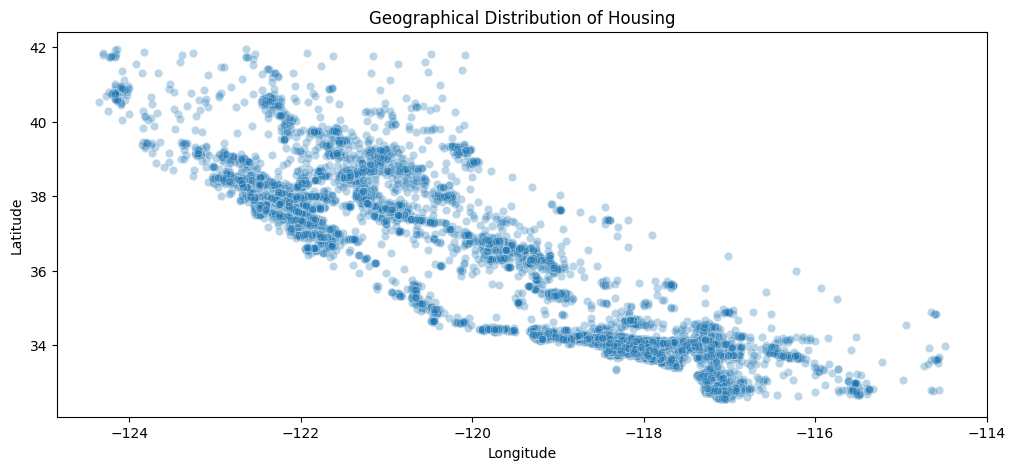

In [426]:
# Visualize the geographical distribution of the housing data
plt.figure(figsize=(12, 5))
sns.scatterplot(data=x_train, x='longitude', y='latitude', alpha=0.3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Housing')
plt.show()

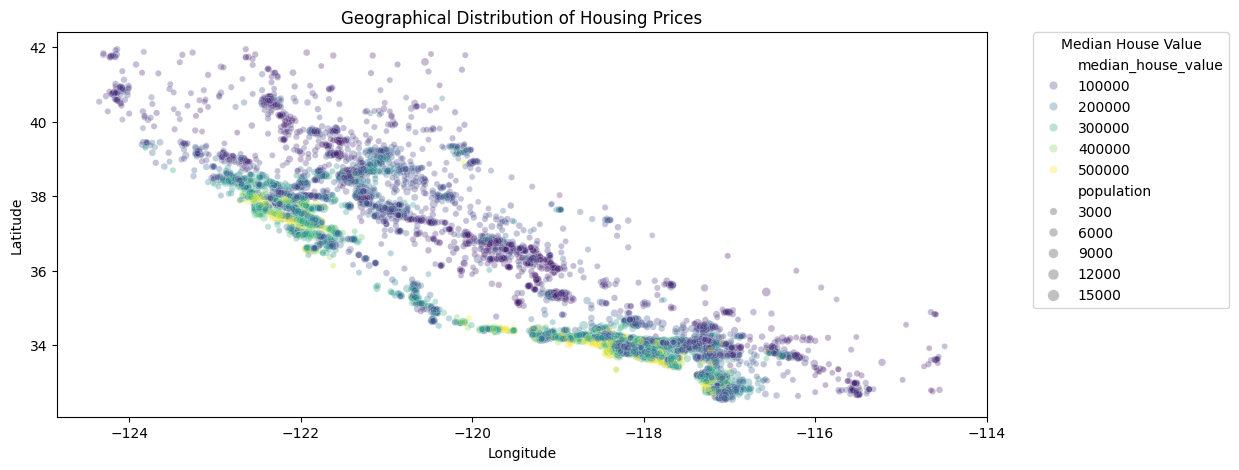

In [427]:
# Visualize housing prices on the map, with point size representing population
plt.figure(figsize=(12, 5))
sns.scatterplot(data=x_train, x='longitude', y='latitude', size='population', hue=y_train, alpha=0.3, palette='viridis')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Housing Prices')
plt.legend(title='Median House Value', bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

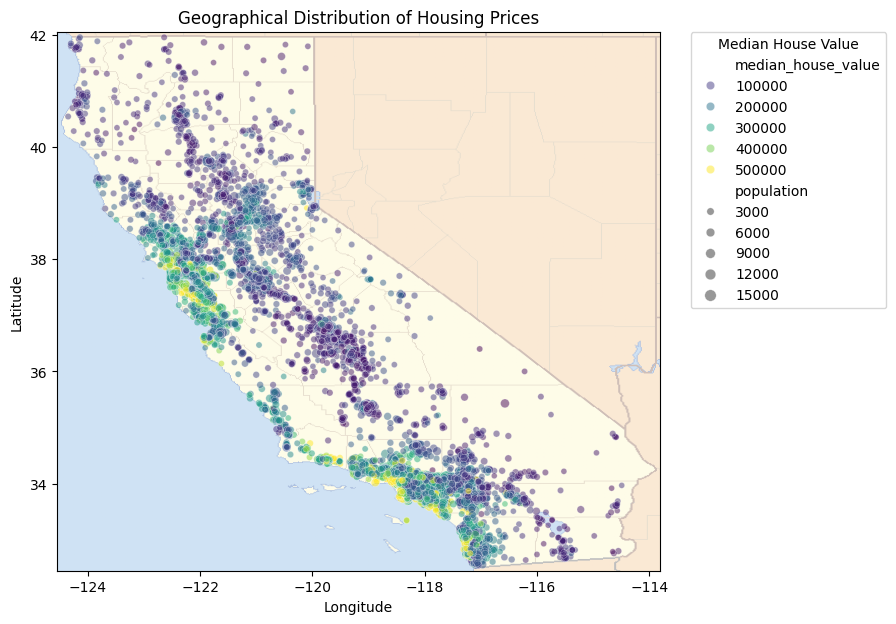

In [428]:
# Overlay the scatter plot on a map of California for better context
url = "https://github.com/ageron/handson-ml3/raw/main/images/end_to_end_project/"
filename = "california.png"

Path("images").mkdir(parents=True, exist_ok=True)
urllib.request.urlretrieve(url=url + filename, filename = "images/" + filename)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=x_train, x='longitude', y='latitude', size='population', hue=y_train, alpha=0.5, palette='viridis')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Housing Prices')
plt.legend(title='Median House Value', bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

california_img = plt.imread("images/" + filename)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5)
plt.show()

The map reveals that house prices are highly related to location, particularly proximity to the coast. It also shows that densely populated areas do not always correspond to the highest prices.

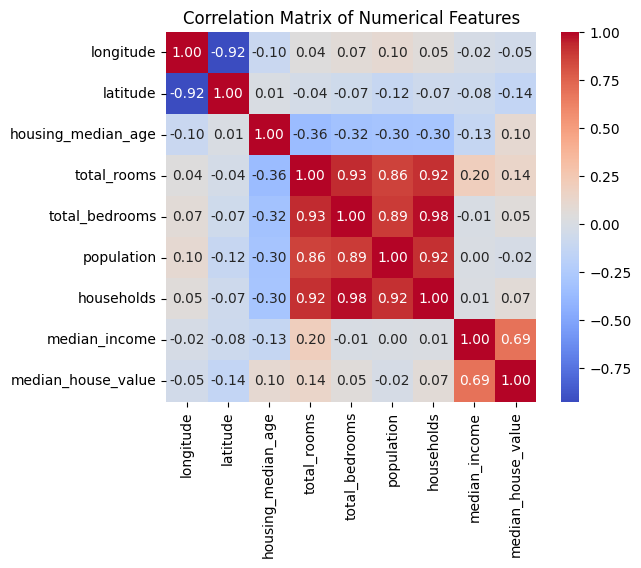

In [429]:
# Evaluate the correlation matrix of numerical features
corr_matrix = pd.concat([x_train.loc[:, x_train.dtypes != 'category'], y_train], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The correlation matrix confirms that `median_income` has the strongest positive correlation with `median_house_value`. Other features show weaker correlations.

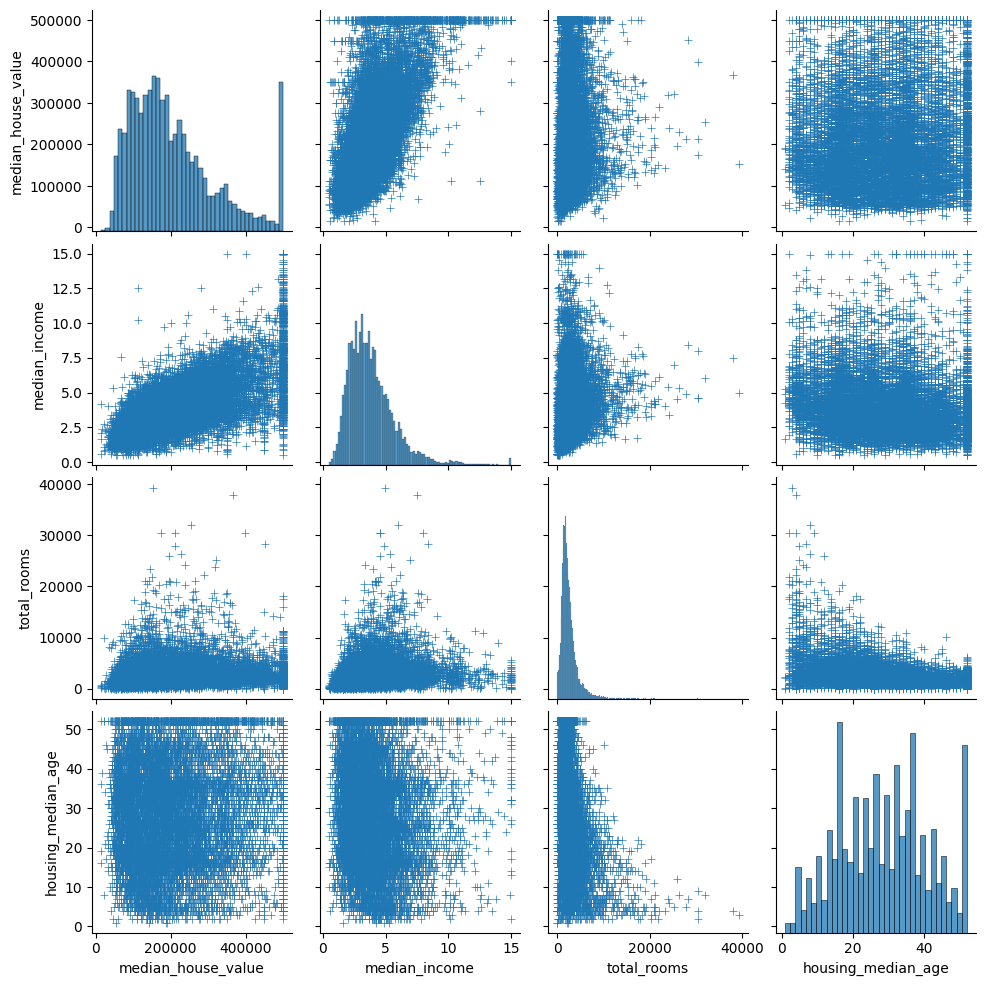

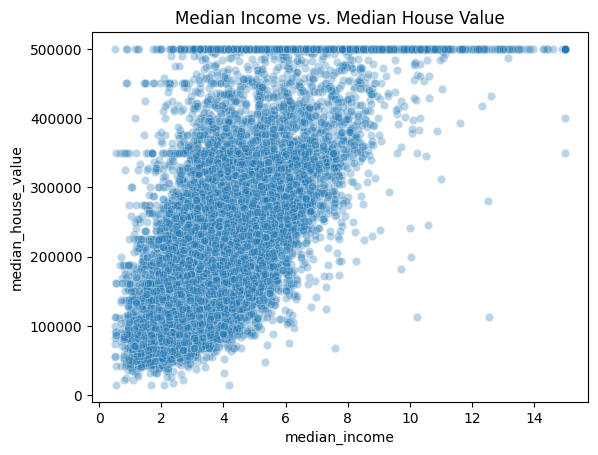

In [430]:
# Focus on the most promising attributes for prediction
attributes = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']
sns.pairplot(data=pd.concat([x_train.loc[:, x_train.dtypes != 'category'], y_train], axis=1), vars=attributes, markers='+')
plt.show()

# Zoom in on the relationship between median income and median house value
sns.scatterplot(data=pd.concat([x_train.loc[:, x_train.dtypes != 'category'], y_train], axis=1), x='median_income', y='median_house_value', alpha=0.3)
plt.title('Median Income vs. Median House Value')
plt.show()

### 2.3. Feature Engineering for Exploration
Based on domain knowledge and the correlation analysis, we can create new features that may have stronger predictive power.

In [431]:
# Create new features based on existing ones
x_train['avg_rooms_per_household'] = x_train['total_rooms'] / x_train['households']
x_train['avg_bedrooms_per_household'] = x_train['total_bedrooms'] / x_train['households']
x_train['bedrooms_rooms_ratio'] = x_train['total_bedrooms'] / x_train['total_rooms']
x_train['avg_people_per_household'] = x_train['population'] / x_train['households']
x_train['avg_individuals_per_bedroom'] = x_train['population'] / x_train['total_bedrooms']

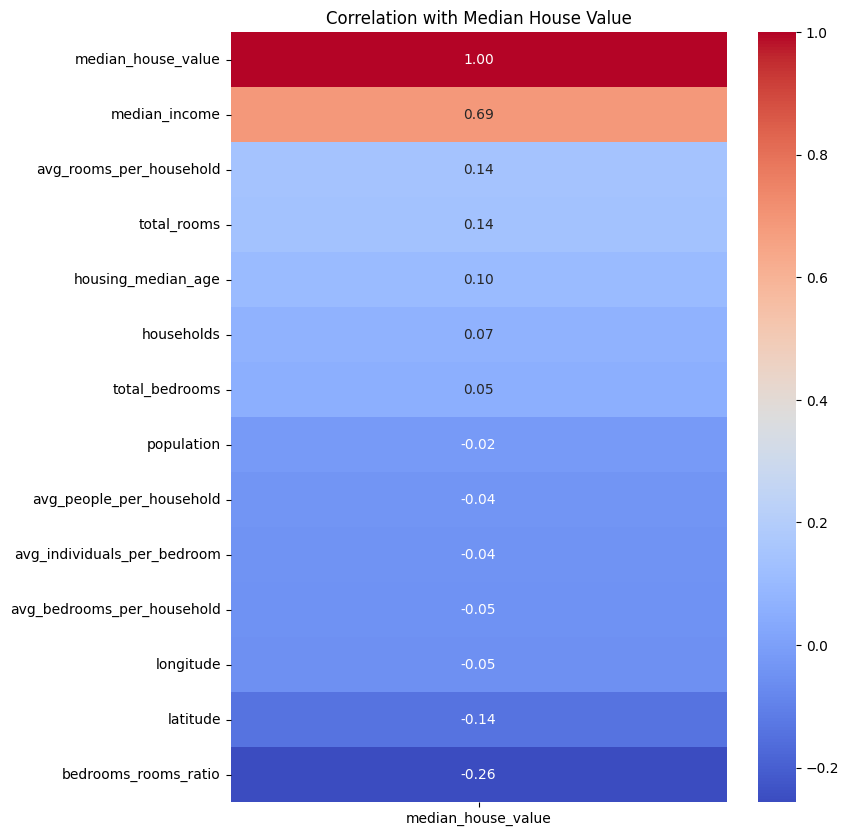

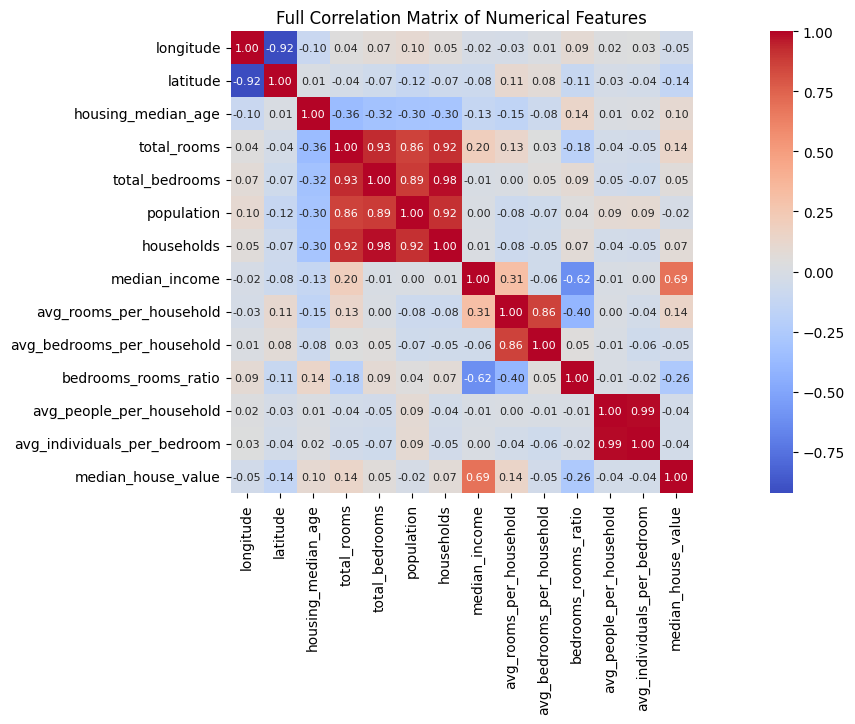

In [432]:
# Re-evaluate the correlation matrix with the new features
corr_matrix = pd.concat([x_train.loc[:, x_train.dtypes != 'category'], y_train], axis=1).corr()

# Focus on correlations with the target variable
plt.figure(figsize=(8, 10))
sns.heatmap(corr_matrix[['median_house_value']].sort_values(by='median_house_value', ascending=False), annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 10})
plt.title('Correlation with Median House Value')
plt.show()

# Display the full correlation matrix
plt.figure(figsize=(20, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, annot_kws={"size": 8})
plt.title('Full Correlation Matrix of Numerical Features')
plt.show()

## 3. Preparing the Data for ML Modelling
This section covers the final data preparation steps before training our models. We'll create a robust preprocessing pipeline to handle imputation, scaling, and feature engineering.

### 3.1. Data Cleaning and Initial Transformation
We'll start by reverting to a clean train/test split and applying initial transformations like imputation and one-hot encoding. This is a temporary step before building the final pipeline.

In [433]:
# Re-create the train-test split to start fresh before building the pipeline
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5], ordered=True)
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(housing.drop('median_house_value', axis=1),
                                                                            housing['median_house_value'],
                                                                            test_size=0.2,
                                                                            random_state=42,
                                                                            stratify=housing['income_cat'])
# Checking the shape of the splits
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape, sep="\n")

# Removing the income_cat attribute so the data is back to its original state
for dataset in (x_train, x_test):
    dataset.drop('income_cat', axis=1, inplace=True)

(16512, 10)
(4128, 10)
(16512,)
(4128,)


In [434]:
# Initial Column Transformer for imputation and one-hot encoding
# Note: This is a preliminary step. The final pipeline will be more comprehensive.
columns_treatment = sklearn.compose.ColumnTransformer([
    ('Imputation', sklearn.impute.SimpleImputer(strategy='median'), np.where((x_train.dtypes != 'category') &
                                                                             ((x_train.columns != 'longitude') &
                                                                              (x_train.columns != 'latitude')))[0]),
    ('OneHot', sklearn.preprocessing.OneHotEncoder(drop=None, sparse_output=False), np.where(x_train.dtypes == 'category')[0])
], remainder='passthrough', verbose_feature_names_out=False)
columns_treatment.set_output(transform='pandas')

x_train = columns_treatment.fit_transform(x_train)

### 3.2. Advanced Feature Engineering
Here, we'll create more complex features, such as location-based clusters, to capture more nuanced patterns in the data.

In [ ]:
# Custom transformer to create location-based clusters using K-Means
class ClusterSimilarity(sklearn.base.TransformerMixin, sklearn.base.BaseEstimator):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
       self.n_clusters = n_clusters
       self.gamma = gamma
       self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = sklearn.cluster.KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return sklearn.metrics.pairwise.rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f'Cluster {i} similarity' for i in range(self.n_clusters)]

In [436]:
# Create and apply the cluster similarity feature
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)
similarities = cluster_simil.fit_transform(x_train[['longitude', 'latitude']], sample_weight=y_train)

# Adding the computed clusters
x_train['Max_clusters_similarity'] = similarities.max(axis= 1)

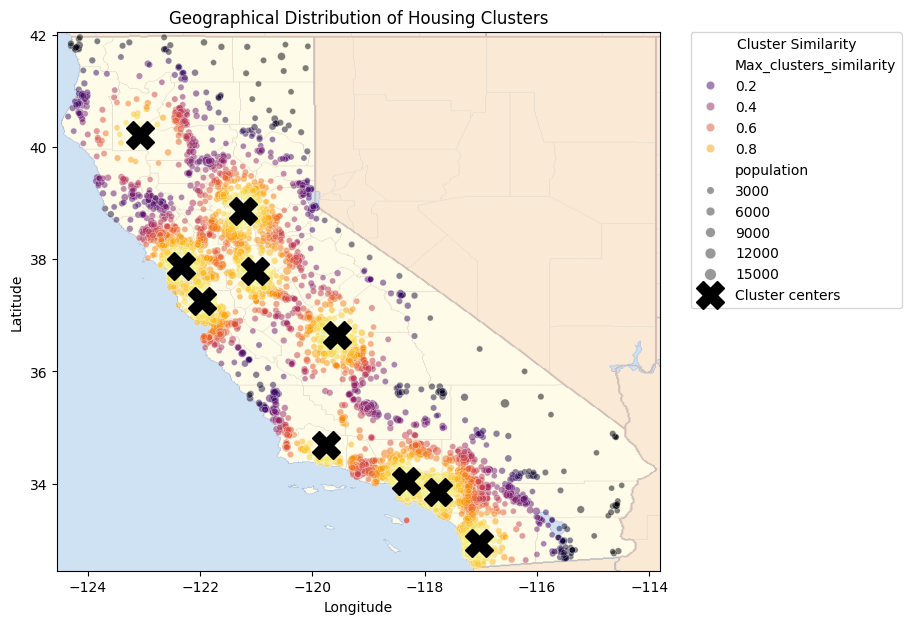

In [437]:
# Visualize the location clusters on the map
plt.figure(figsize=(10, 7))
# Getting the main scatter plot
sns.scatterplot(data=x_train, x='longitude', y='latitude', size='population',
                hue='Max_clusters_similarity', alpha=0.5, palette='inferno')

# Plot the cluster centers
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 0],
         cluster_simil.kmeans_.cluster_centers_[:, 1],
         linestyle='', color='black', marker='X', markersize=20,
         label='Cluster centers')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Housing Clusters')
plt.legend(title='Cluster Similarity', bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

california_img = plt.imread("images/" + filename)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5)
plt.show()

### 3.3. Building the Final Preprocessing Pipeline
Now we'll assemble all the transformation steps into a single, organized pipeline. This ensures that the same steps are applied consistently to both the training and testing data.

In [438]:
# Re-create the train-test split one last time to ensure a clean slate
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5], ordered=True)
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(housing.drop('median_house_value', axis=1),
                                                                            housing['median_house_value'],
                                                                            test_size=0.2,
                                                                            random_state=42,
                                                                            stratify=housing['income_cat'])
# Checking the shape of the splits
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape, sep="\n")

# Removing the income_cat attribute so the data is back to its original state
for dataset in (x_train, x_test):
    dataset.drop('income_cat', axis=1, inplace=True)

(16512, 10)
(4128, 10)
(16512,)
(4128,)


In [439]:
# Custom functions for the pipeline
def column_ratio(X):
    """Computes ratio-based features."""
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    """Generates a name for the ratio feature."""
    return ["ratio"]

def ratio_pipeline():
    """Creates a pipeline for ratio-like metrics."""
    return sklearn.pipeline.make_pipeline(
        sklearn.impute.SimpleImputer(strategy="median"),
        sklearn.preprocessing.FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        sklearn.preprocessing.StandardScaler())

In [440]:
# Creating base pipelines for numeric variables:
def ratio_pipeline():
    return sklearn.pipeline.make_pipeline(
        sklearn.impute.SimpleImputer(strategy="median"),
        sklearn.preprocessing.FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        sklearn.preprocessing.StandardScaler())

log_pipeline = sklearn.pipeline.make_pipeline(
    sklearn.impute.SimpleImputer(strategy='median'),
    sklearn.preprocessing.FunctionTransformer(np.log, inverse_func=np.exp, feature_names_out='one-to-one'),
    sklearn.preprocessing.StandardScaler()
)
cluster_simil = Cluster(n_clusters=10, gamma=1.0, random_state=42)

num_pipe = sklearn.pipeline.Pipeline(
    steps= [('Impute', sklearn.impute.SimpleImputer(strategy="median")),
            ('Scaler', sklearn.preprocessing.StandardScaler())]
)

# Creating base pipeline for categorical variables
cat_pipe = sklearn.pipeline.Pipeline(
    steps=[('Impute', sklearn.impute.SimpleImputer(strategy='most_frequent')),
           ('OneHot', sklearn.preprocessing.OneHotEncoder(handle_unknown='ignore', sparse_output=False))]
)

In [441]:
# Assemble the final preprocessing pipeline using ColumnTransformer
preprocessing = sklearn.compose.ColumnTransformer([
    ('bedrooms', ratio_pipeline(), ['total_bedrooms', 'total_rooms']),
    ('rooms_per_house', ratio_pipeline(), ['total_rooms', 'households']),
    ('people_per_house', ratio_pipeline(), ['population', 'households']),
    ('people_per_bedroom', ratio_pipeline(), ['population', 'total_bedrooms']),
    ('log', log_pipeline, ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']),
    ('geo', cluster_simil, ['latitude', 'longitude']),
    ('cat', cat_pipe, sklearn.compose.make_column_selector(dtype_include='category'))
], remainder='passthrough', verbose_feature_names_out=False
)

preprocessing

,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [442]:
x_train = preprocessing.fit_transform(x_train)

In [444]:
x_train.shape

(16512, 25)

## 4. Data Modelling
Now that the data is prepared, we'll move on to the modeling stage. We will train and evaluate several regression models to find the one that best predicts the median house value. Given that larger errors are more critical for this task, we will use the Root Mean Squared Error (RMSE) as our primary evaluation metric.